## access hugging face for our data and a transformer model 

In [3]:
import sys
print(sys.executable)

/Users/scholtbolt/git/GeoML_Ops_Command/geospatial_workflows/venv/bin/python


In [12]:
!pip install -r requirements.txt

  Using cached torch-2.2.2-cp38-none-macosx_10_9_x86_64.whl.metadata (25 kB)
  Using cached torchvision-0.17.2-cp38-cp38-macosx_10_13_x86_64.whl.metadata (6.6 kB)
  Using cached datasets-3.1.0-py3-none-any.whl.metadata (20 kB)
  Using cached evaluate-0.4.3-py3-none-any.whl.metadata (9.2 kB)
  Using cached notebook-7.4.3-py3-none-any.whl.metadata (10 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2025.3.0-py3-none-any.whl.metadata (11 kB)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached huggingface_hub-0.33.0-py3-none-any.whl.metadata (14 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached safetensors-0.5.3-cp38-abi3-macosx_10_12_x86_64.whl.metadata (3.8 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached cycler-0.12.1-py3-none-a

In [7]:
from huggingface_hub import notebook_login
notebook_login()

ModuleNotFoundError: No module named 'huggingface_hub'

###kristin kodes krazy

In [5]:
from datasets import Dataset, load_dataset, concatenate_datasets

ModuleNotFoundError: No module named 'datasets'

In [2]:
ds = load_dataset("gdurkin/iowa_hyper_jun_24",verification_mode='no_checks') # or "gdurkin/s1_nlcd_ca" "gdurkin/s1_nlcd_sfbay_plus"
ds_merged = concatenate_datasets([ds[k] for k in list(ds.keys())])
ds_split = ds_merged.train_test_split(test_size=0.1, seed=42)
dataset_train = ds_split['train'] #,download_mode = "force_redownload")['train']
dataset_test = ds_split['test'] #,download_mode = "force_redownload")['train']

/usr/local/Cellar/python@3.11/3.11.9_1/Frameworks/Python.framework/Versions/3.11/lib/python3.11/importlib/__init__.py:126: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.3.0)
  return _bootstrap._gcd_import(name[level:], package, level)


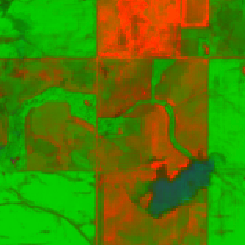

In [4]:
dataset_train[0]['pixel_values']

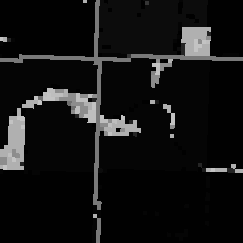

In [5]:
dataset_train[0]['labels']

In [6]:
type(dataset_train[0]['labels'])

PIL.PngImagePlugin.PngImageFile

In [7]:
import torch, torchvision
import datasets
print(torch.__version__)            # e.g. "2.0.1"
print(torchvision.__version__)     # should be ≥ "0.15.0"
from torchvision.transforms import v2
print(v2)  # should not error



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.0 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/scholtbolt/Library/Python/3.11/lib/python/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/scholtbolt/Library/Python/3.11/lib/python/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
  File "/Users/scholtbolt/Library/Python/3.11/lib/python/site-packages/ipykernel/kernelapp.py", line 739, in start
    self.io

2.2.2
0.17.2
<module 'torchvision.transforms.v2' from '/usr/local/lib/python3.11/site-packages/torchvision/transforms/v2/__init__.py'>


## load dataset from hub

In [8]:
from datasets import load_dataset

# ds = load_dataset("gdurkin/iowa_hyper_jun_24")['train']



# dataset_train = load_dataset("gdurkin/cdl_training",use_auth_token=True)['train'] #,download_mode = "force_redownload")['train']
# dataset_test = load_dataset("gdurkin/cdl_testing",use_auth_token=True)['train'] #,download_mode = "force_redownload")['train']

In [9]:
# from datasets import Dataset, load_dataset, concatenate_datasets
# ds = load_dataset("gdurkin/iowa_hyper_jun_24",verification_mode='no_checks') # or "gdurkin/s1_nlcd_ca" "gdurkin/s1_nlcd_sfbay_plus"
# ds_merged = concatenate_datasets([ds[k] for k in list(ds.keys())])
# ds_split = ds_merged.train_test_split(test_size=0.1, seed=42)
# dataset_train = ds_split['train'] #,download_mode = "force_redownload")['train']
# dataset_test = ds_split['test'] #,download_mode = "force_redownload")['train']

In [10]:
# dataset_holdout = ds["group_0_5"]   # 254 rows
# dataset_test    = ds["group_12_14"]  # 494 rows
# dataset_train    = ds["group_6_11"]    # 972 rows


In [11]:
len(dataset_train)
len(dataset_test)

172

### some in place transforms

In [12]:
from torchvision.transforms.v2 import Compose, ToPILImage
from torchvision.transforms import ToTensor   # v1 transform

In [13]:

def prep_dataset_train(examples):
    transform_seq = v2.Compose([v2.ToPILImage(),
                                #v2.RandomHorizontalFlip(p=0.3),
                                #v2.RandomVerticalFlip(p=0.3),
                                #v2.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.05, hue=0.05),
        #v2.RandomResizedCrop(scale=(0.25, 1.0),size=(512, 512), antialias=True),
                           v2.PILToTensor(),
                                v2.ToDtype(torch.float32, scale=True)
                               ]) 
    toPIL = v2.ToPILImage()
    images = [toPIL(x) for x in examples['pixel_values']]
    labels = [toPIL(y) for y in examples['labels']]
    aug_list = zip(images,labels)
    augmented_batch = [transform_seq(el) for el in aug_list]
    images, labels = zip(*augmented_batch) 
    encoding = {}
    encoding["pixel_values"] = [torch.tensor(el).float().to(device) for el in images]
    encoding['labels'] = [torch.tensor(el).long().squeeze().to(device) for el in labels]
    return encoding #{"pixel_values": encoding['pixel_values'], "labels": encoding['labels']} 

def prep_dataset_validate(examples):
    transform_seq = v2.Compose([v2.ToPILImage(),
                           v2.PILToTensor(),
                                v2.ToDtype(torch.float32, scale=True)
                               ]) 
    toPIL = v2.ToPILImage()
    images = [toPIL(x) for x in examples['pixel_values']]
    labels = [toPIL(y) for y in examples['labels']]
    aug_list = zip(images,labels)
    augmented_batch = [transform_seq(el) for el in aug_list]
    images, labels = zip(*augmented_batch) 
    encoding = {}
    encoding["pixel_values"] = [torch.tensor(el).float() for el in images]
    encoding['labels'] = [torch.tensor(el).long().squeeze() for el in labels]
    return encoding 

dataset_train.set_transform(prep_dataset_train)
dataset_test.set_transform(prep_dataset_validate)

In [14]:
import numpy as np
import torch
from torchvision.transforms.v2 import Compose, ToPILImage, ToDtype

def pil_to_float_tensor(pic):
    arr = np.array(pic, copy=True)
    # convert uint8→float32 and scale to [0,1]
    return torch.as_tensor(arr, dtype=torch.float32).permute(2,0,1) / 255.0

transform_seq = Compose([
    ToPILImage(),
    pil_to_float_tensor,    # ← our custom converter
    # you don’t even need the ToDtype step any more
])


### load model

In [15]:
if torch.backends.mps.is_built():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

In [16]:
device

device(type='mps')

In [17]:
class_color_dict = {0: 'background', 1: 'water', 2: 'developed', 3: 'corn', 
               4: 'soybeans', 5: 'wheat', 6: 'other agriculture', 
               7: 'forest/wetlands', 8: 'open lands', 9: 'barren'}

id2label = class_color_dict 
label2id = {v: k for k, v in id2label.items()}
num_labels = len(id2label)
print("Id2label:", id2label)
print("label2Id:", label2id)

#PATH = '/xxx'

#pretrained_model_name = "nvidia/segformer-b0-finetuned-ade-512-512"

#model.load_state_dict(torch.load(PATH))

Id2label: {0: 'background', 1: 'water', 2: 'developed', 3: 'corn', 4: 'soybeans', 5: 'wheat', 6: 'other agriculture', 7: 'forest/wetlands', 8: 'open lands', 9: 'barren'}
label2Id: {'background': 0, 'water': 1, 'developed': 2, 'corn': 3, 'soybeans': 4, 'wheat': 5, 'other agriculture': 6, 'forest/wetlands': 7, 'open lands': 8, 'barren': 9}


Convert your images and labels to numpy arrays or PIL Images before converting to tensors


In [18]:
# from torchvision.transforms import ToTensor
# import torch
# import numpy as np

# def preprocess(example):
#     # Convert image to tensor [3, H, W]
#     img = example['pixel_values']
#     if hasattr(img, 'convert'):
#         img = img.convert('RGB')
#     img = ToTensor()(img)  # Now a torch tensor

#     # Convert label to tensor [H, W]
#     lbl = example['labels']
#     if hasattr(lbl, 'convert'):
#         lbl = lbl.convert('L')
#     lbl = torch.as_tensor(np.array(lbl), dtype=torch.long)

#     return {'pixel_values': img, 'labels': lbl}

In [19]:
# dataset_train = dataset_train.map(preprocess)

### try a state of the art model - mask2former

In [20]:
from transformers import AutoImageProcessor, Mask2FormerForUniversalSegmentation

# load Mask2Former fine-tuned on Mapillary Vistas semantic segmentation


fb_model = "facebook/mask2former-swin-large-mapillary-vistas-semantic"
my_model = "gdurkin/cdl_mask2former_hi_res_v3"



loaded_model = Mask2FormerForUniversalSegmentation.from_pretrained(fb_model,
    label2id=label2id,
    id2label = id2label,
    num_labels=num_labels,
    ignore_mismatched_sizes=True,
)

loaded_model = loaded_model.to(device)

# not a problem to get the following message, it goes away once you start training. It only occurs beacuse the pre-trained model was trained on a different number of classes: [You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference]

Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-large-mapillary-vistas-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([66]) in the checkpoint and torch.Size([11]) in the model instantiated
- class_predictor.weight: found shape torch.Size([66, 256]) in the checkpoint and torch.Size([11, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([66]) in the checkpoint and torch.Size([11]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [38]:
from transformers import Mask2FormerImageProcessor
from torch.utils.data import DataLoader
# Create a preprocessor
preprocessor = Mask2FormerImageProcessor(ignore_index=0, reduce_labels=False, do_resize=False, do_rescale=False, do_normalize=False)

def collate_fn_mask(batch):
    
    if not isinstance(batch, list):
        batch = list(batch.items())  
    images = [el['pixel_values'] for el in batch]
    segmentation_maps =  [el['labels'] for el in batch]
    segmentation_maps = [torch.as_tensor(arr, dtype=torch.long, device=device) for arr in segmentation_maps]

    try:
        batch = preprocessor(
            images,
            segmentation_maps=segmentation_maps,
            return_tensors="pt",
        )
        batch["original_images"] = images
        batch["original_segmentation_maps"] = segmentation_maps
    except:
        batch = None
    return batch

test_dataloader = DataLoader(dataset_test, batch_size=1, shuffle=True, collate_fn=collate_fn_mask)
train_dataloader = DataLoader(dataset_train, batch_size=2, shuffle=True, collate_fn=collate_fn_mask)

#larger batch sizes may cause your vram to saturate OOM

In [2]:
which python

SyntaxError: invalid syntax (1722139382.py, line 1)

In [39]:
import torch
import torchvision
import numpy
import datasets
from transformers import __version__ as transformers_version

print(f"PyTorch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"NumPy: {numpy.__version__}")
print(f"Datasets: {datasets.__version__}")
print(f"Transformers: {transformers_version}")

PyTorch: 2.2.2
TorchVision: 0.17.2
NumPy: 2.3.0
Datasets: 3.6.0
Transformers: 4.52.4


In [6]:
import sys
print(sys.executable)

/usr/local/opt/python@3.11/bin/python3.11


In [5]:
import sys
print(sys.executable)

/usr/local/opt/python@3.11/bin/python3.11


In [ ]:
import sys
print(sys.executable)

/usr/local/opt/python@3.11/bin/python3.11


In [ ]:
import sys
print(sys.executable)

/usr/local/opt/python@3.11/bin/python3.11


In [ ]:
import sys
print(sys.executable)

/usr/local/opt/python@3.11/bin/python3.11


In [40]:
import platform
print(platform.system())  # Windows, macOS, Linux
print(platform.machine())  # x86_64, arm64, etc.

Darwin
x86_64


In [41]:
import torch
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"Device: {torch.device('cuda' if torch.cuda.is_available() else 'cpu')}")

CUDA available: False
MPS available: True
Device: cpu


In [42]:
# !pip uninstall torch torchvision numpy datasets transformers
# !pip install torch torchvision numpy datasets transformers

In [43]:
batch = next(iter(train_dataloader))

RuntimeError: Could not infer dtype of numpy.uint8

In [44]:
batch = next(iter(train_dataloader))

RuntimeError: Could not infer dtype of numpy.uint8

In [146]:
for k,v in batch.items():
  if isinstance(v, torch.Tensor):
    print(k,v.shape)
  else:
    print(k,v[0].shape)

NameError: name 'batch' is not defined

In [45]:
pixel_values = batch["pixel_values"][0].numpy()
pixel_values.shape

NameError: name 'batch' is not defined

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(pixel_values.transpose(1,2,0))

NameError: name 'pixel_values' is not defined

In [14]:
import evaluate
metric = evaluate.load("mean_iou")

In [15]:
epoch_count = 30 #let's just make sure things are working, then we can go to 50 or 100

### training loop:

In [ ]:
from tqdm.auto import tqdm
optimizer = torch.optim.Adam(loaded_model.parameters(), lr=5e-5)

running_loss = 0.0
num_samples = 0
import pandas as pd 
df_metrics =  pd.DataFrame(columns=[])

for epoch in range(epoch_count):
  print("Epoch:", epoch)
  loaded_model.train()
  #i = 0
  for idx, batch in enumerate(tqdm(train_dataloader)):
      # i+=1
      # if i>5:
      #     break
      # Reset the parameter gradients
      optimizer.zero_grad()
      try:

      # Forward pass
          outputs = loaded_model(
              pixel_values=batch["pixel_values"].to(device),
              mask_labels=[labels.to(device) for labels in batch["mask_labels"]],
              class_labels=[labels.to(device) for labels in batch["class_labels"]],
          )
      except Exception as e:
          print(e)
          continue
    

      # Backward propagation
      loss = outputs.loss
      loss.backward()

      batch_size = batch["pixel_values"].size(0)
      running_loss += loss.item()
      num_samples += batch_size

      if idx % 250 == 0:
        print("Loss:", running_loss/num_samples)

      # Optimization
      optimizer.step()

  loaded_model.eval()
  for idx, batch in enumerate(tqdm(test_dataloader)):
    
    #   break
    try:
        if idx % 1000 == 0:
            pixel_values = batch["pixel_values"][0]
            
            # Forward pass
            with torch.no_grad():
                outputs = loaded_model(pixel_values=pixel_values.unsqueeze(0).to(device))
              
            # get original images
            original_images = batch["original_images"]
            target_sizes = [(original_images[0].shape[1],original_images[0].shape[2])]
        # predict segmentation maps
        
            predicted_segmentation_maps = preprocessor.post_process_semantic_segmentation(outputs,
                                                                                      target_sizes=target_sizes)[0]
            # get ground truth segmentation maps
            ground_truth_segmentation_maps = batch["original_segmentation_maps"][0]
    
            metric.add_batch(references=ground_truth_segmentation_maps, predictions=predicted_segmentation_maps)
            ground_truth_segmentation_maps = ground_truth_segmentation_maps.cpu()
            predicted_segmentation_maps = predicted_segmentation_maps.cpu()
            #print("Mean IoU:", metric.compute(num_labels = len(id2label), ignore_index = 0)['mean_iou'])
            metrics = metric._compute(references=ground_truth_segmentation_maps, predictions=predicted_segmentation_maps,
                            num_labels= len(id2label),
                            ignore_index=0, # missing data,
                            reduce_labels=False, #processor.do_reduce_labels 
                        #nan_to_num=0,
                    )
            
                    # add per category metrics as individual key-value pairs
            per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
            per_category_iou = metrics.pop("per_category_iou").tolist()
            
            #metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
            metrics_update = {f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)}
            metrics_update['epoch'] = epoch
            metrics_update['loss'] = running_loss/num_samples
            df_metrics  = pd.concat([df_metrics, pd.DataFrame([metrics_update])], ignore_index=True)
        
            print(metrics_update)
          
    except Exception as e:
        print(e)
        continue


Epoch: 0


  0%|          | 0/4125 [00:00<?, ?it/s]

/tmp/ipykernel_4790/2850638860.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  encoding["pixel_values"] = [torch.tensor(el).float().to(device) for el in images]
/tmp/ipykernel_4790/2850638860.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  encoding['labels'] = [torch.tensor(el).long().squeeze().to(device) for el in labels]


Loss: 55.13684844970703
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
Loss: 39.59463828457289
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
'NoneType' object is not subscriptable
Loss: 37.35518046418826
'NoneType' object is not subscriptable
Loss: 35.74782219639531
'NoneType' object is not subscriptable
'NoneTy

In [ ]:
df_metrics

In [ ]:
df_metrics[['iou_water','iou_developed','iou_corn','iou_soybeans','iou_other agriculture']].plot()

### we can save the model locally and also push it to hugging face:

In [ ]:
import os
code_path = os.getcwd()
model_dir = "mask2former_cdl_models"
os.makedirs(model_dir, exist_ok=True)
print(code_path)

model_name = 'cdl-mask2former_v0'


PATH = code_path + '/' +model_dir + '/' + model_name
print('PATH =',PATH)

torch.save(loaded_model.state_dict(), PATH)

In [ ]:
loaded_model.push_to_hub("gdurkin/cdl_mask2former_v0)